In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scipy.io

# Load data
mat_contents = scipy.io.loadmat('hw5_A.mat')  
A_mat = mat_contents['A']  # The variable named 'A' inside hw5_A.mat

# Check if A_mat is already sparse or dense, Convert it to sparse if needed.
if sp.issparse(A_mat):
    A_sparse = A_mat
else:
    A_sparse = sp.csr_matrix(A_mat)


## Ex. a

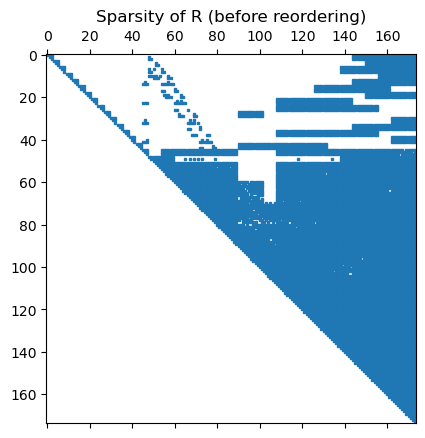

Number of nonzero entries in R before reordering: 9315


In [2]:
# Compute R from QR factorization 
A_dense = A_sparse.toarray()  # convert to dense
Q, R = np.linalg.qr(A_dense, mode='reduced')  # yields Q (m x n), R (n x n)

# Plot sparsity pattern of R and count nonzeros
plt.figure()
plt.spy(R, markersize=2)
plt.title("Sparsity of R (before reordering)")
plt.show()

nnz_before = np.count_nonzero(R)
print("Number of nonzero entries in R before reordering:", nnz_before)

## Ex. b

In [6]:
# install scikit-sparse if needed: pip install scikit-sparse

from sksparse.cholmod import cholesky, colamd

# COLAMD reordering
#    We'll do this by factoring A^T A with CHOLMOD, since the Cholesky factor L
#    gives us R = L^T.  The variable ordering used in that factorization
#    is basically what you’d get from a “sparse QR”.
A_csc = A_sparse.tocsc()

# Get COLAMD column ordering
col_order = colamd(A_csc)  # permutation of columns

# Reorder columns of A
A_reordered = A_csc[:, col_order]

# Compute A_reordered^T * A_reordered
AtA_reordered = A_reordered.T @ A_reordered

# Factor (A_reordered^T * A_reordered) via Cholesky
factor = cholesky(AtA_reordered)
L = factor.L()       # L is lower-triangular
R_reordered = L.T    # R = L^T

ModuleNotFoundError: No module named 'sksparse'

In [ ]:
plt.figure()
plt.spy(R_reordered, markersize=2)
plt.title("Sparsity of R (after COLAMD re-ordering)")
plt.show()

nnz_after = R_reordered.count_nonzero()
print("Number of nonzero entries in R after reordering:", nnz_after)

print(f"Nonzeros before = {nnz_before}, after = {nnz_after}.")
print("We’ll typically see a significant reduction in fill by using COLAMD.")
